In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('graduate_admission1.csv')

In [3]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA,Research,Chance of Admit
0,295,96,2,4.9,1.7,2.93,0,0.612
1,340,119,3,4.1,1.7,3.76,0,0.708
2,336,96,1,3.2,1.8,3.12,1,0.728
3,337,108,4,3.4,1.3,2.11,0,0.643
4,323,98,1,1.1,1.3,3.40,0,0.524


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          1000 non-null   int64  
 1   TOEFL Score        1000 non-null   int64  
 2   University Rating  1000 non-null   int64  
 3   SOP                1000 non-null   float64
 4   LOR                1000 non-null   float64
 5   GPA                1000 non-null   float64
 6   Research           1000 non-null   int64  
 7   Chance of Admit    1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


In [7]:
df.duplicated().sum()

0

In [9]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [12]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [14]:
model = Sequential()

model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(1,activation='linear'))

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 7)                 56        
                                                                 
 dense_1 (Dense)             (None, 1)                 8         
                                                                 
Total params: 64 (256.00 Byte)
Trainable params: 64 (256.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
model.compile(loss='mean_squared_error',optimizer='Adam')

history = model.fit(X_train_scaled,y_train,epochs=10,validation_split=0.2)


Epoch 1/10

20/20 [==============================] - 2s 20ms/step - loss: 0.2173 - val_loss: 0.1587
Epoch 2/10
20/20 [==============================] - 0s 7ms/step - loss: 0.1033 - val_loss: 0.0684
Epoch 3/10
20/20 [==============================] - 0s 7ms/step - loss: 0.0472 - val_loss: 0.0348
Epoch 4/10
20/20 [==============================] - 0s 7ms/step - loss: 0.0303 - val_loss: 0.0269
Epoch 5/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0251 - val_loss: 0.0235
Epoch 6/10
20/20 [==============================] - 0s 7ms/step - loss: 0.0214 - val_loss: 0.0203
Epoch 7/10
20/20 [==============================] - 0s 7ms/step - loss: 0.0182 - val_loss: 0.0177
Epoch 8/10
20/20 [==============================] - 0s 7ms/step - loss: 0.0157 - val_loss: 0.0155
Epoch 9/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0136 - val_loss: 0.0138
Epoch 10/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0121 - val_loss: 0.0122


In [16]:
model.compile(loss='mean_squared_error',optimizer='Adam')

In [17]:
history = model.fit(X_train_scaled,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
20/20 [==============================] - 1s 16ms/step - loss: 0.0097 - val_loss: 0.0088
Epoch 2/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0074 - val_loss: 0.0066
Epoch 3/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 4/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0053 - val_loss: 0.0047
Epoch 5/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0048 - val_loss: 0.0042
Epoch 6/10
20/20 [==============================] - 0s 7ms/step - loss: 0.0044 - val_loss: 0.0038
Epoch 7/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0041 - val_loss: 0.0034
Epoch 8/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0037 - val_loss: 0.0030
Epoch 9/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0035 - val_loss: 0.0028
Epoch 10/10
20/20 [==============================] - 0s 6ms/step - loss: 0.0033 - val_loss: 0.0026


In [18]:
y_pred = model.predict(X_test_scaled)

from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

7/7 [==============================] - 0s 1ms/step


0.6624482413960087

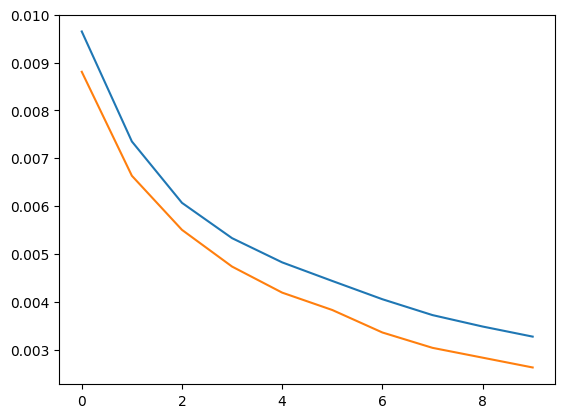

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])